In [ ]:
## 

In [1]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(user='root', password='nsti', host='localhost', database='GP')
cursor = conn.cursor()

query = "SELECT * FROM transactions"
cursor.execute(query)

# Fetch all rows
rows = cursor.fetchall()

# Get column names
columns = [desc[0] for desc in cursor.description]

# Create DataFrame
df = pd.DataFrame(rows, columns=columns)
print(df)


   id  user_id        date       category   amount     type
0   1      101  2025-01-01         Salary  1000.00   income
1   2      101  2025-01-02           Food   200.00  expense
2   3      101  2025-01-03      Transport    50.00  expense
3   4      101  2025-01-04  Entertainment   100.00  expense
4   5      102  2025-01-07         Salary  1200.00   income
5   6      102  2025-01-08           Rent   500.00  expense
6   7      102  2025-01-09      Groceries   300.00  expense
7   8      102  2025-01-10      Utilities   150.00  expense


In [2]:

summary = df.groupby(['user_id','type'])['amount'].sum().unstack()
print(summary)




type    expense   income
user_id                 
101      350.00  1000.00
102      950.00  1200.00


In [3]:
summary['savings'] = summary['income'] - summary['expense']
print(summary)

type    expense   income savings
user_id                         
101      350.00  1000.00  650.00
102      950.00  1200.00  250.00


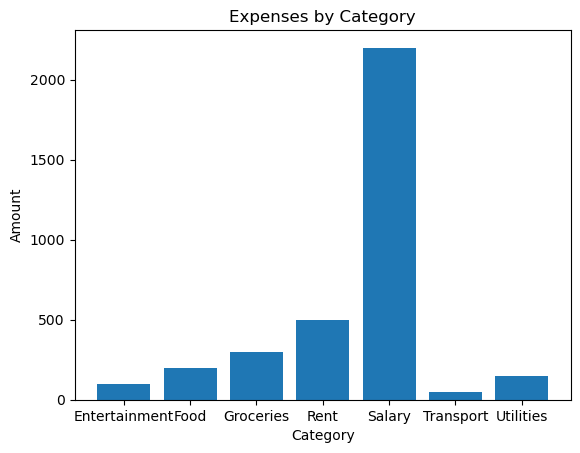

In [4]:
import matplotlib.pyplot as plt

Cat_A = df.groupby('category')['amount'].sum()
plt.bar(Cat_A.index, Cat_A.values)
plt.title("Expenses by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.show()
